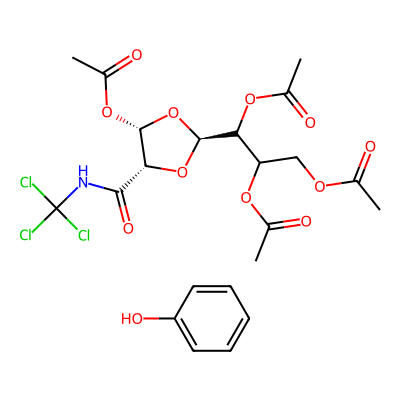

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

# Schmidt trichloroacetimidate glycosylation phenol

# Reactant
reactant = Chem.MolFromSmiles('c1ccc(cc1)O.O=C(NC(Cl)(Cl)Cl)[C@H]1O[C@@H](O[C@H]1OC(C)=O)C(OC(C)=O)C(OC(C)=O)COC(C)=O')
display(Draw.MolToImage(reactant, size=(400, 400)))

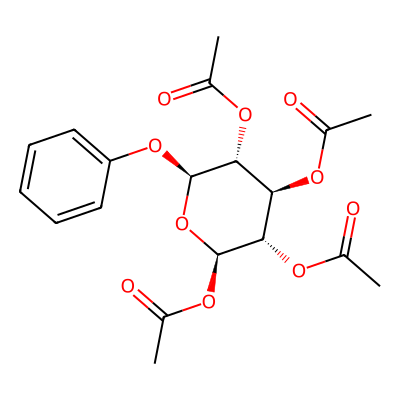

In [2]:
# Product
product = Chem.MolFromSmiles('c1ccc(cc1)O[C@@H]2O[C@H](OC(C)=O)[C@@H](OC(C)=O)[C@H](OC(C)=O)[C@H]2OC(C)=O')
display(Draw.MolToImage(product, size=(400, 400)))

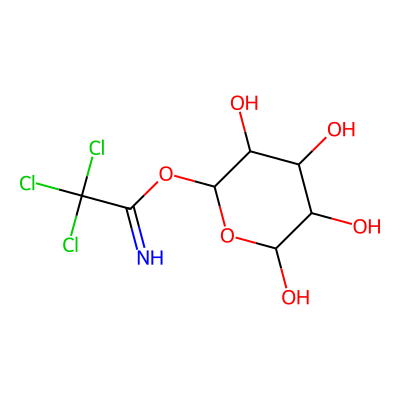

In [3]:
# Try
test = Chem.MolFromSmiles('C1(O)OC(OC(=N)C(Cl)(Cl)Cl)C(O)C(O)C1(O)')
display(Draw.MolToImage(test, size=(400, 400)))

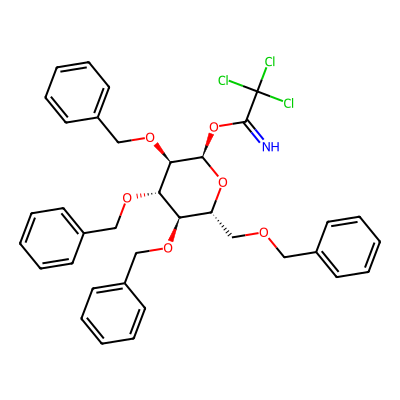

In [ ]:
test = Chem.MolFromSmiles('[C@H]1(COCc2ccccc2)O[C@H](OC(=N)C(Cl)(Cl)Cl)[C@H](OCc3ccccc3)[C@@H](OCc4ccccc4)[C@@H]1(OCc5ccccc5)')
display(Draw.MolToImage(test, size=(400, 400)))

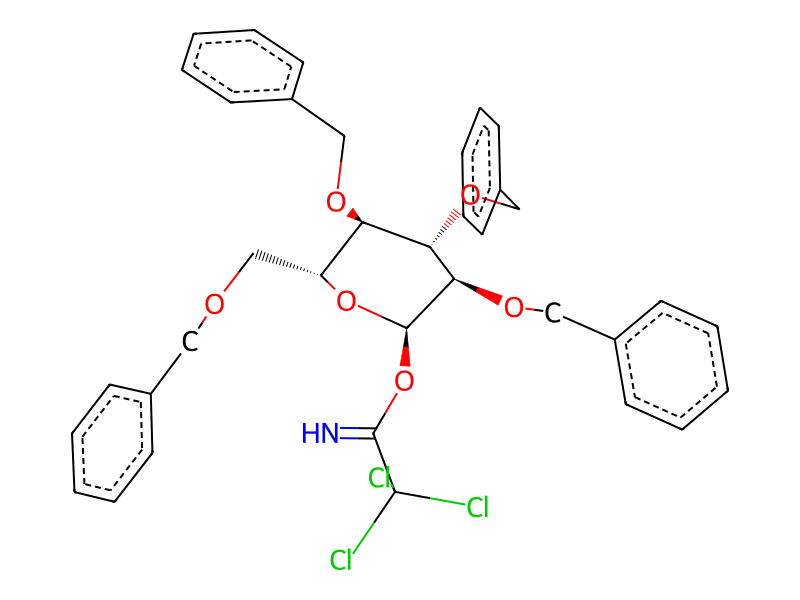

In [28]:
test = Chem.AddHs(test)
AllChem.EmbedMolecule(test)
AllChem.MMFFOptimizeMolecule(test)

conf = test.GetConformer()
coords_3d = conf.GetPositions()

# 简单的透视投影：z轴压缩，制造深度感
# 投影到xy平面，但用z坐标调整大小或位置
z = coords_3d[:, 2]
x = coords_3d[:, 0] + 0.3 * z  # 透视偏移
y = coords_3d[:, 1] - 0.2 * z

# 创建新分子，设置2D坐标
from copy import deepcopy
mol_2d = deepcopy(test)
conf_2d = Chem.Conformer(mol_2d.GetNumAtoms())
for i in range(mol_2d.GetNumAtoms()):
    conf_2d.SetAtomPosition(i, Chem.rdGeometry.Point3D(x[i], y[i], 0))
mol_2d.AddConformer(conf_2d)

# 绘制（使用这个"伪3D"的2D坐标）
mol_2d = Chem.RemoveHs(mol_2d)  # 去掉氢原子以简化图像
display(Draw.MolToImage(mol_2d, size=(800, 600), kekulize=False))
